In [2]:
# ============================================================
# NOTEBOOK 5 — ANOMALY DETECTION
# Convolutional Autoencoder trained on WALKING only
# Reconstruction error = anomaly score
# This is the pathological gait detection component:
# High reconstruction error → unusual gait → potential pathology
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import os

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Load preprocessed windows
save_dir = '/content/drive/MyDrive/DL_Project_Gait/data/processed'
X_train = np.load(f'{save_dir}/X_train.npy')
y_train = np.load(f'{save_dir}/y_train.npy')
X_test  = np.load(f'{save_dir}/X_test.npy')
y_test  = np.load(f'{save_dir}/y_test.npy')

# Label mapping (0-indexed)
activity_names = {
    0: 'walking', 1: 'running', 2: 'going_up', 3: 'going_down',
    4: 'sitting', 5: 'sitting_down', 6: 'standing_up', 7: 'standing',
    8: 'up_elevator', 9: 'down_elevator'
}

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

# ============================================================
# EXTRACT WALKING-ONLY WINDOWS FOR TRAINING THE AUTOENCODER
# Class 0 = walking (after remapping)
# ============================================================
walking_class = 0
X_walk_train = X_train[y_train == walking_class]
X_walk_test  = X_test[y_test == walking_class]

print(f"\nWalking windows for autoencoder training: {len(X_walk_train)}")
print(f"Walking windows for autoencoder testing:  {len(X_walk_test)}")
print(f"\nThe autoencoder learns ONLY healthy walking patterns.")
print(f"High reconstruction error on other activities = anomaly detected.")

Mounted at /content/drive
Device: cuda
X_train: (10274, 128, 36)
X_test:  (4607, 128, 36)

Walking windows for autoencoder training: 2962
Walking windows for autoencoder testing:  1305

The autoencoder learns ONLY healthy walking patterns.
High reconstruction error on other activities = anomaly detected.


In [3]:
# ============================================================
# CONVOLUTIONAL AUTOENCODER
# Encoder compresses gait signal → latent space
# Decoder reconstructs it back
# MSE reconstruction error = anomaly score
# ============================================================

class GaitAutoencoder(nn.Module):
    def __init__(self, n_channels=36, seq_len=128):
        super().__init__()

        # ENCODER — compress (36, 128) → (64, 16)
        self.encoder = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2),                               # (64, 64)

            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2),                               # (32, 32)

            nn.Conv1d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16), nn.ReLU(),
            nn.MaxPool1d(2),                               # (16, 16)
        )

        # DECODER — reconstruct (16, 16) → (36, 128)
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2),                   # (16, 32)
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),

            nn.Upsample(scale_factor=2),                   # (32, 64)
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(),

            nn.Upsample(scale_factor=2),                   # (64, 128)
            nn.Conv1d(64, n_channels, kernel_size=7, padding=3),
        )

    def forward(self, x):           # x: (batch, channels, seq_len)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def get_reconstruction_error(self, x):
        """Per-sample MSE reconstruction error."""
        with torch.no_grad():
            reconstructed = self.forward(x)
            # MSE per sample: mean over channels and time
            error = ((x - reconstructed) ** 2).mean(dim=[1, 2])
        return error


# Test architecture
ae_model = GaitAutoencoder().to(DEVICE)
total_params = sum(p.numel() for p in ae_model.parameters())
print(f"Autoencoder parameters: {total_params:,}")

dummy = torch.randn(4, 36, 128).to(DEVICE)
out = ae_model(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}  (should match input)")
print("\n✓ Autoencoder architecture correct!")

Autoencoder parameters: 56,468
Input shape:  torch.Size([4, 36, 128])
Output shape: torch.Size([4, 36, 128])  (should match input)

✓ Autoencoder architecture correct!


Training autoencoder on 2962 walking windows only...
Input tensor shape: torch.Size([2962, 36, 128])

Training...
--------------------------------------------------
  Epoch   5/30 | MSE Loss: 0.511136
  Epoch  10/30 | MSE Loss: 0.442918
  Epoch  15/30 | MSE Loss: 0.415398
  Epoch  20/30 | MSE Loss: 0.404761
  Epoch  25/30 | MSE Loss: 0.394491
  Epoch  30/30 | MSE Loss: 0.392043


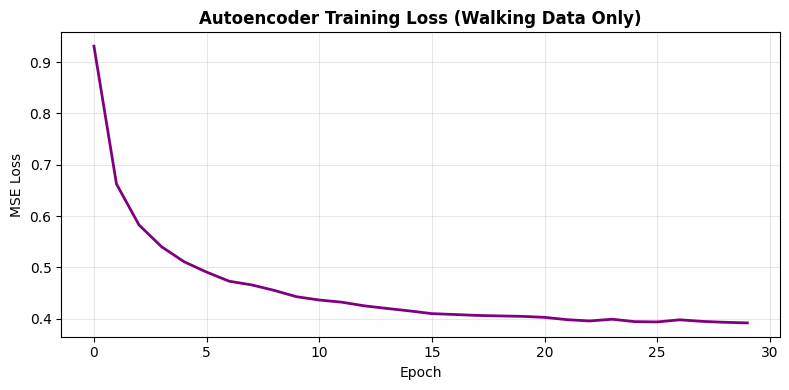


✓ Autoencoder trained and saved!


In [4]:
# Prepare DataLoader — ONLY walking windows
# Autoencoder input: (batch, channels, seq_len) — transpose needed
X_walk_tensor = torch.FloatTensor(X_walk_train).permute(0, 2, 1)  # (N, 36, 128)
walk_dataset  = TensorDataset(X_walk_tensor, X_walk_tensor)        # input = target
walk_loader   = DataLoader(walk_dataset, batch_size=64, shuffle=True)

print(f"Training autoencoder on {len(X_walk_tensor)} walking windows only...")
print(f"Input tensor shape: {X_walk_tensor.shape}")

# Train
ae_model   = GaitAutoencoder().to(DEVICE)
ae_optim   = torch.optim.Adam(ae_model.parameters(), lr=1e-3)
ae_criterion = nn.MSELoss()
ae_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ae_optim, T_max=30)

ae_losses = []
N_AE_EPOCHS = 30

print("\nTraining...")
print("-" * 50)
for epoch in range(N_AE_EPOCHS):
    ae_model.train()
    epoch_loss = 0
    for X_batch, _ in walk_loader:
        X_batch = X_batch.to(DEVICE)
        ae_optim.zero_grad()
        reconstructed = ae_model(X_batch)
        loss = ae_criterion(reconstructed, X_batch)
        loss.backward()
        ae_optim.step()
        epoch_loss += loss.item()
    ae_scheduler.step()
    avg_loss = epoch_loss / len(walk_loader)
    ae_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:3d}/{N_AE_EPOCHS} | MSE Loss: {avg_loss:.6f}")

# Save autoencoder
ae_path = '/content/drive/MyDrive/DL_Project_Gait/models/autoencoder_best.pth'
torch.save(ae_model.state_dict(), ae_path)

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(ae_losses, color='purple', linewidth=2)
plt.title('Autoencoder Training Loss (Walking Data Only)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DL_Project_Gait/results/autoencoder_loss.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Autoencoder trained and saved!")

Mean reconstruction error per activity:
-------------------------------------------------------
  0 walking             : mean=0.9876  std=0.5310  n=1305
  1 running             : mean=4.4807  std=1.7368  n=283
  2 going_up            : mean=0.7226  std=0.3397  n=467
  3 going_down          : mean=0.9617  std=0.4193  n=451
  4 sitting             : mean=0.3015  std=0.0727  n=344
  5 sitting_down        : mean=0.2319  std=0.1119  n=59
  6 standing_up         : mean=0.2319  std=0.0937  n=91
  7 standing            : mean=0.0699  std=0.0766  n=994
  8 up_elevator         : mean=0.0436  std=0.0220  n=319
  9 down_elevator       : mean=0.0460  std=0.0432  n=294


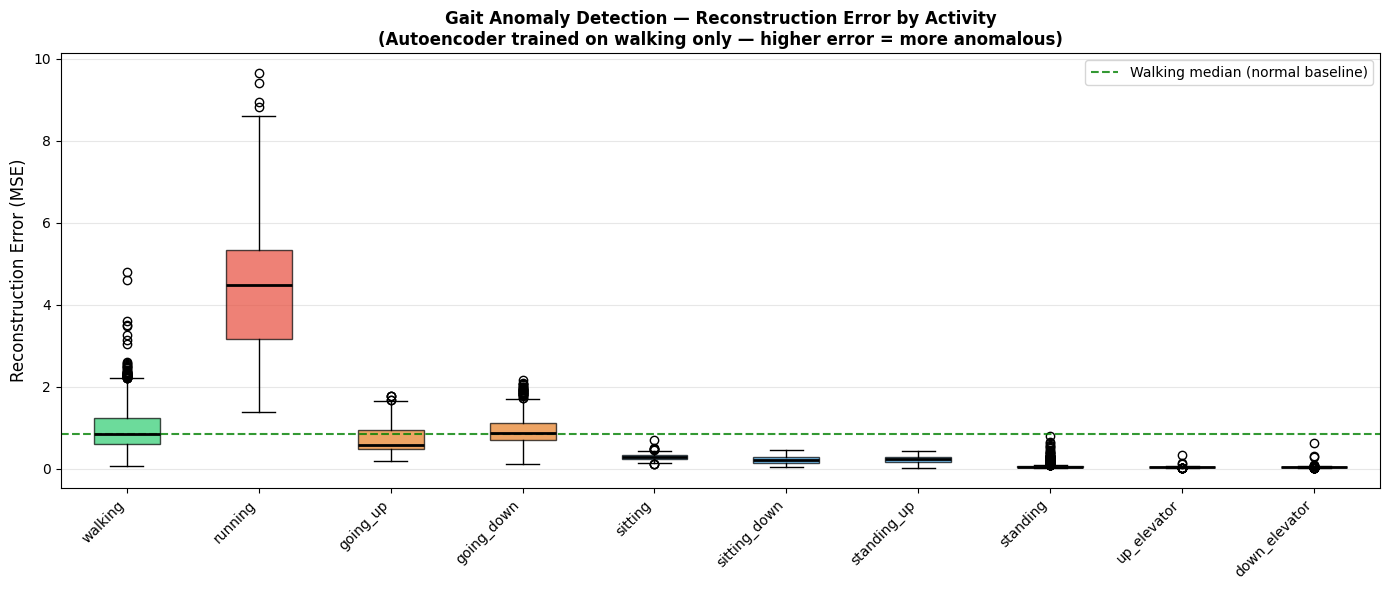


✓ Anomaly detection boxplot saved!

KEY FINDING: Activities different from walking show higher
reconstruction error, demonstrating the anomaly detection
capability that would flag pathological gait in clinical use.


In [5]:
# ============================================================
# COMPUTE RECONSTRUCTION ERROR FOR EVERY TEST WINDOW
# The core anomaly detection result
# ============================================================

ae_model.eval()

# Prepare all test windows in CNN format: (N, 36, 128)
X_test_ae = torch.FloatTensor(X_test).permute(0, 2, 1)

# Compute reconstruction error per sample in batches
all_errors = []
batch_size = 128

with torch.no_grad():
    for i in range(0, len(X_test_ae), batch_size):
        batch = X_test_ae[i:i+batch_size].to(DEVICE)
        errors = ae_model.get_reconstruction_error(batch)
        all_errors.extend(errors.cpu().numpy())

all_errors = np.array(all_errors)

# Group errors by activity
print("Mean reconstruction error per activity:")
print("-" * 55)
errors_by_class = {}
for class_id in range(10):
    mask = y_test == class_id
    if mask.sum() > 0:
        class_errors = all_errors[mask]
        errors_by_class[class_id] = class_errors
        name = activity_names[class_id]
        print(f"  {class_id} {name:20s}: mean={class_errors.mean():.4f}  "
              f"std={class_errors.std():.4f}  n={mask.sum()}")

# ============================================================
# BOXPLOT — The key anomaly detection visualization
# Walking should have LOWEST reconstruction error
# Other activities should have HIGHER error
# This demonstrates the anomaly detection capability
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

data_to_plot = []
labels_to_plot = []
colors_list = []

# Define color: walking = green (normal), others = red shades (anomalous)
color_map = {
    0: '#2ecc71',  # walking — green (normal)
    1: '#e74c3c',  2: '#e67e22',  3: '#e67e22',
    4: '#3498db',  5: '#3498db',  6: '#3498db',
    7: '#3498db',  8: '#9b59b6',  9: '#9b59b6'
}

for class_id, errors in sorted(errors_by_class.items()):
    data_to_plot.append(errors)
    labels_to_plot.append(activity_names[class_id])
    colors_list.append(color_map.get(class_id, '#95a5a6'))

bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(labels_to_plot, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Reconstruction Error (MSE)', fontsize=12)
ax.set_title('Gait Anomaly Detection — Reconstruction Error by Activity\n'
             '(Autoencoder trained on walking only — higher error = more anomalous)',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add annotation
ax.axhline(y=np.median(errors_by_class[0]), color='green',
           linestyle='--', alpha=0.8, linewidth=1.5,
           label='Walking median (normal baseline)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DL_Project_Gait/results/anomaly_detection_boxplot.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Anomaly detection boxplot saved!")
print("\nKEY FINDING: Activities different from walking show higher")
print("reconstruction error, demonstrating the anomaly detection")
print("capability that would flag pathological gait in clinical use.")